# Task 1: Deep Convolutional Autoencoder (DCAE) on CIFAR-10
Reconstruct images from a 512-dimensional latent representation, then cluster and visualize embeddings.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from skimage.metrics import structural_similarity as ssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Load CIFAR-10

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print(f"Classes: {class_names}")
print(f"Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Training samples: 50000, Test samples: 10000


### Display example images

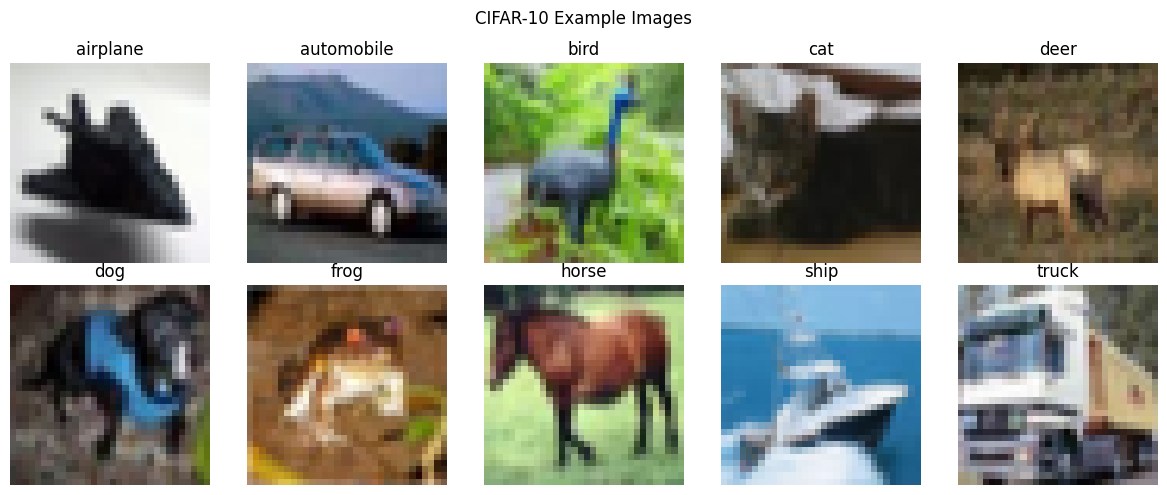

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    idx = next(j for j, (_, label) in enumerate(train_dataset) if label == i)
    img, label = train_dataset[idx]
    ax = axes[i // 5, i % 5]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(class_names[label])
    ax.axis('off')
plt.suptitle('CIFAR-10 Example Images')
plt.tight_layout()
plt.show()

## 2. Define the Deep Convolutional Autoencoder

In [3]:
class DCAE(nn.Module):
    def __init__(self, latent_dim=512):
        super(DCAE, self).__init__()

        # Encoder: 3x32x32 -> latent_dim
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),   # -> 32x16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),   # -> 64x8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # -> 128x4x4
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), # -> 256x2x2
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        self.encoder_fc = nn.Linear(256 * 2 * 2, latent_dim)

        # Decoder: latent_dim -> 3x32x32
        self.decoder_fc = nn.Linear(latent_dim, 256 * 2 * 2)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1), # -> 128x4x4
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # -> 64x8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),   # -> 32x16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),    # -> 3x32x32
            nn.Sigmoid(),
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.view(x.size(0), -1)
        x = self.encoder_fc(x)
        return x

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(x.size(0), 256, 2, 2)
        x = self.decoder_conv(x)
        return x

    def forward(self, x):
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon

model = DCAE(latent_dim=512).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

DCAE(
  (encoder_conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
  )
  (encoder_fc): Linear(in_features=1024, out_features=512, bias=True)
  (decoder_fc): Linear(in_features=512, out_features=1024, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2

## 3. Train the DCAE

In [4]:
import os

checkpoint_path = 'checkpoints/dcae_cifar10.pth'

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 50

train_losses = []
test_losses = []

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        train_losses = checkpoint.get('train_losses', [])
        test_losses = checkpoint.get('test_losses', [])
        print(f"Loaded checkpoint from '{checkpoint_path}' ({len(train_losses)} epochs)")
    else:
        # Legacy format: file contains only the state dict
        model.load_state_dict(checkpoint)
        print(f"Loaded model weights from '{checkpoint_path}' (no loss history)")
else:
    print("Training from scratch!")
    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        running_loss = 0.0
        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                outputs = model(images)
                loss = criterion(outputs, images)
                running_loss += loss.item()
        test_loss = running_loss / len(test_loader)
        test_losses.append(test_loss)

        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")

    torch.save({
        'model_state_dict': model.state_dict(),
        'train_losses': train_losses,
        'test_losses': test_losses,
    }, checkpoint_path)
    print(f"Model saved to '{checkpoint_path}'")

Loaded model weights from 'checkpoints/dcae_cifar10.pth' (no loss history)


### Training and validation loss curves

ValueError: x and y must have same first dimension, but have shapes (50,) and (0,)

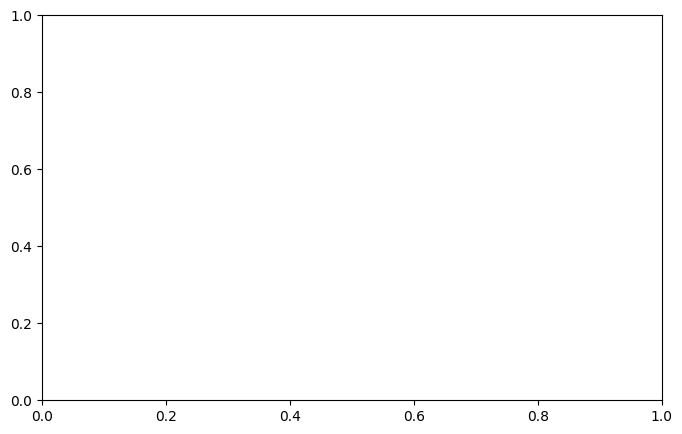

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('DCAE Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Qualitative Evaluation — Original vs. Reconstructed

In [ ]:
model.eval()
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

images_np = images.cpu().numpy()
outputs_np = outputs.cpu().numpy()

n = 10
fig, axes = plt.subplots(2, n, figsize=(15, 3))
for i in range(n):
    axes[0, i].imshow(np.transpose(images_np[i], (1, 2, 0)))
    axes[0, i].axis('off')
    axes[1, i].imshow(np.transpose(outputs_np[i], (1, 2, 0)))
    axes[1, i].axis('off')
fig.text(0.01, 0.75, 'Original', fontsize=12, va='center', ha='left')
fig.text(0.01, 0.25, 'Reconstructed', fontsize=12, va='center', ha='left')
plt.suptitle('DCAE Reconstruction Results on CIFAR-10 Test Set')
plt.tight_layout(rect=[0.08, 0, 1, 0.95])
plt.show()

## 5. Quantitative Evaluation — MSE and SSIM on Test Set

In [ ]:
model.eval()
mse_scores = []
ssim_scores = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)

        imgs_np = images.cpu().numpy()
        outs_np = outputs.cpu().numpy()

        for i in range(imgs_np.shape[0]):
            orig = np.transpose(imgs_np[i], (1, 2, 0))
            recon = np.transpose(outs_np[i], (1, 2, 0))
            mse_scores.append(np.mean((orig - recon) ** 2))
            ssim_scores.append(ssim(orig, recon, data_range=1.0, channel_axis=2))

print(f"Test MSE:  {np.mean(mse_scores):.6f} (+/- {np.std(mse_scores):.6f})")
print(f"Test SSIM: {np.mean(ssim_scores):.4f} (+/- {np.std(ssim_scores):.4f})")

NameError: name 'model' is not defined

## 6. Extract 512-dim Embeddings

In [6]:
model.eval()
all_embeddings = []
all_labels = []

full_dataset = torch.utils.data.ConcatDataset([train_dataset, test_dataset])
full_loader = DataLoader(full_dataset, batch_size=256, shuffle=False, num_workers=2)

with torch.no_grad():
    for images, labels in full_loader:
        images = images.to(device)
        embeddings = model.encode(images)
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(labels.numpy())

all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
print(f"Embeddings shape: {all_embeddings.shape}")
print(f"Labels shape: {all_labels.shape}")

Embeddings shape: (60000, 512)
Labels shape: (60000,)


## 7. PCA (512 → 10) and K-Means Clustering

In [7]:
pca = PCA(n_components=10)
embeddings_pca = pca.fit_transform(all_embeddings)
print(f"PCA embeddings shape: {embeddings_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(embeddings_pca)
print(f"\nK-Means labels shape: {kmeans_labels.shape}")

PCA embeddings shape: (60000, 10)
Explained variance ratio: [0.1426185  0.09370669 0.0677789  0.05367441 0.04390309 0.03756978
 0.03682909 0.02945509 0.02610387 0.02336733]
Total explained variance: 0.5550


C:\Users\kingj2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\kingj2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kingj2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend


K-Means labels shape: (60000,)


### Clustering Evaluation Metrics (ARI and NMI)

In [8]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from scipy.optimize import linear_sum_assignment

# ARI: adjusted for chance, robust to label permutation; range [-1, 1], 1 = perfect
ari = adjusted_rand_score(all_labels, kmeans_labels)

# NMI: information overlap between clusterings; range [0, 1], 1 = perfect
nmi = normalized_mutual_info_score(all_labels, kmeans_labels, average_method='arithmetic')

# Clustering accuracy: find optimal label mapping via the Hungarian algorithm
cm = confusion_matrix(all_labels, kmeans_labels)
row_ind, col_ind = linear_sum_assignment(cm.max() - cm)
cluster_acc = cm[row_ind, col_ind].sum() / cm.sum()

print(f"Adjusted Rand Index (ARI): {ari:.4f}  (chance=0, perfect=1)")
print(f"Normalized Mutual Info  (NMI): {nmi:.4f}  (0=no overlap, 1=perfect)")
print(f"Clustering Accuracy (best mapping): {cluster_acc:.4f} ({cluster_acc*100:.2f}%)")

# Show the optimal cluster → class mapping
mapping = {col_ind[i]: class_names[row_ind[i]] for i in range(len(row_ind))}
print(f"\nOptimal cluster → class mapping:")
for cluster_id in sorted(mapping):
    print(f"  Cluster {cluster_id} → {mapping[cluster_id]}")

Adjusted Rand Index (ARI): 0.0477  (chance=0, perfect=1)
Normalized Mutual Info  (NMI): 0.0910  (0=no overlap, 1=perfect)
Clustering Accuracy (best mapping): 0.2091 (20.91%)

Optimal cluster → class mapping:
  Cluster 0 → airplane
  Cluster 1 → dog
  Cluster 2 → ship
  Cluster 3 → truck
  Cluster 4 → horse
  Cluster 5 → frog
  Cluster 6 → deer
  Cluster 7 → bird
  Cluster 8 → automobile
  Cluster 9 → cat


## 8. t-SNE Visualization (PCA 10-dim → 2D)

In [ ]:
# Use a subset for t-SNE (full 60k is slow)
n_samples = 10000
rng = np.random.RandomState(42)
indices = rng.choice(len(embeddings_pca), n_samples, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings_pca[indices])
print(f"t-SNE embeddings shape: {embeddings_2d.shape}")

t-SNE embeddings shape: (10000, 2)


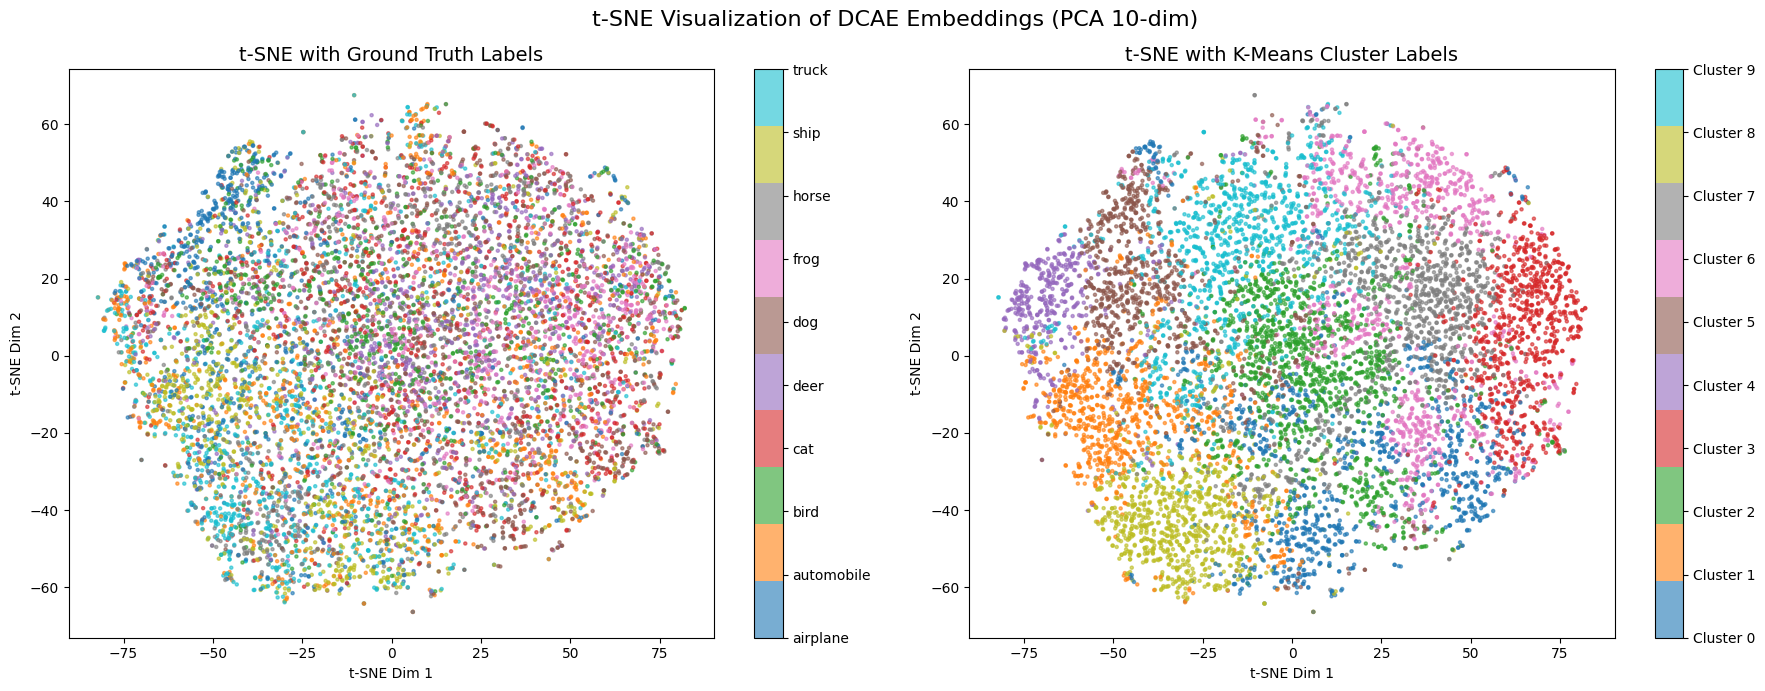

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Ground truth labels
scatter1 = axes[0].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                           c=all_labels[indices], cmap='tab10', s=5, alpha=0.6)
axes[0].set_title('t-SNE with Ground Truth Labels', fontsize=14)
axes[0].set_xlabel('t-SNE Dim 1')
axes[0].set_ylabel('t-SNE Dim 2')
cbar1 = plt.colorbar(scatter1, ax=axes[0], ticks=range(10))
cbar1.set_ticklabels(class_names)

# K-Means labels
scatter2 = axes[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                           c=kmeans_labels[indices], cmap='tab10', s=5, alpha=0.6)
axes[1].set_title('t-SNE with K-Means Cluster Labels', fontsize=14)
axes[1].set_xlabel('t-SNE Dim 1')
axes[1].set_ylabel('t-SNE Dim 2')
cbar2 = plt.colorbar(scatter2, ax=axes[1], ticks=range(10))
cbar2.set_ticklabels([f'Cluster {i}' for i in range(10)])

plt.suptitle('t-SNE Visualization of DCAE Embeddings (PCA 10-dim)', fontsize=16)
plt.tight_layout()
plt.show()